# Feature Engineering — Fraud_Data.csv
**Adey Innovations Inc. | Fraud Detection | Week 5 & 6**

**Objective:** Build and validate all engineered features. Run the full preprocessing pipeline and save processed datasets ready for model training.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_preprocessing import (
    preprocess_fraud_data,
    preprocess_creditcard,
    apply_smote,
    apply_undersampling,
)
from feature_engineering import (
    add_time_since_signup,
    add_temporal_features,
    add_transaction_velocity,
    encode_categoricals,
    label_encode_country,
)
from sklearn.model_selection import train_test_split

BLUE = '#2E75B6'; CORAL = '#E95D4F'; GREEN = '#70AD47'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

print('Imports OK.')

Imports OK.


---
## 1. Feature 1 — time_since_signup

time_since_signup stats:
count      151112.00
mean      4932029.25
std       3126263.12
min             1.00
25%       2186753.50
50%       4926345.50
75%       7644524.50
max      10367972.00
Name: time_since_signup, dtype: float64



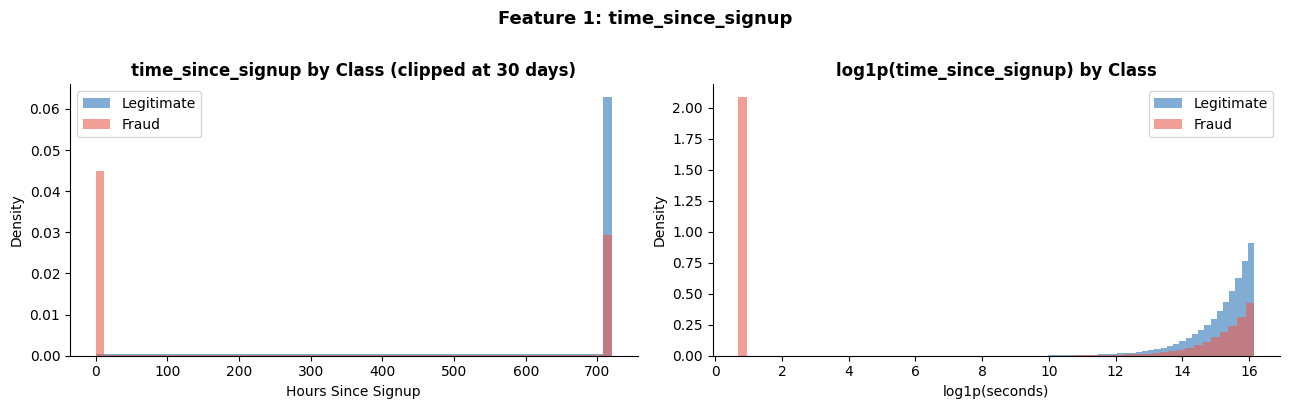

In [2]:
raw = pd.read_csv('../data/raw/Fraud_Data.csv')
df  = add_time_since_signup(raw.copy())

print('time_since_signup stats:')
print(df['time_since_signup'].describe().round(2))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls, color, lbl in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    vals = df[df['class']==cls]['time_since_signup'].clip(0, 3600*24*30) / 3600
    axes[0].hist(vals, bins=60, alpha=0.6, color=color, density=True, label=lbl, edgecolor='none')
axes[0].set_title('time_since_signup by Class (clipped at 30 days)', fontweight='bold')
axes[0].set_xlabel('Hours Since Signup')
axes[0].set_ylabel('Density')
axes[0].legend()

# Log transform
df['log_time_since_signup'] = np.log1p(df['time_since_signup'])
for cls, color, lbl in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    vals = df[df['class']==cls]['log_time_since_signup']
    axes[1].hist(vals, bins=60, alpha=0.6, color=color, density=True, label=lbl, edgecolor='none')
axes[1].set_title('log1p(time_since_signup) by Class', fontweight='bold')
axes[1].set_xlabel('log1p(seconds)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Feature 1: time_since_signup', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fe_time_since_signup.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Feature 2 — Temporal Features (hour_of_day, day_of_week)

2026-06-08 06:29:12,213 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-08 06:29:12,216 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


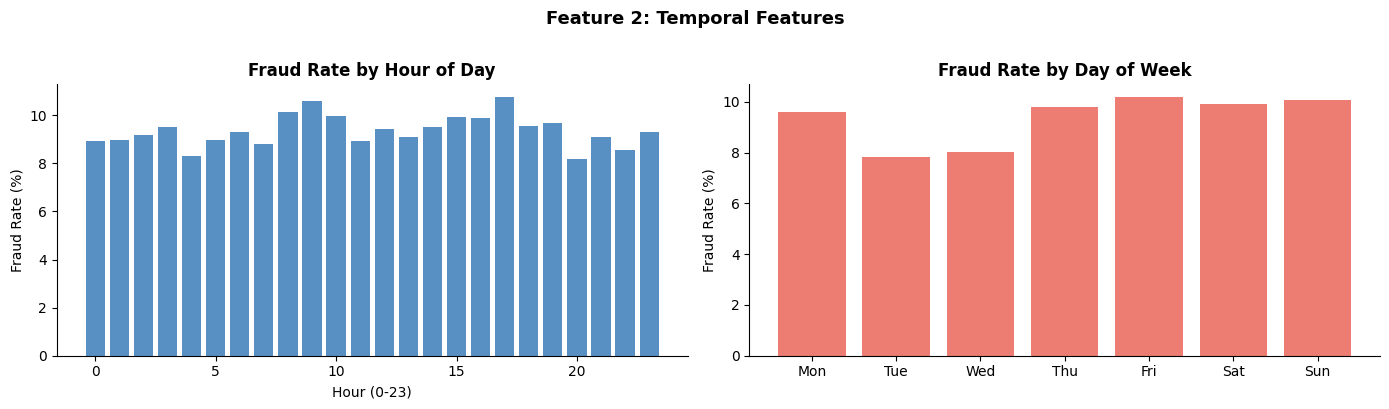

In [3]:
df = add_temporal_features(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_fraud = df.groupby('hour_of_day')['class'].mean() * 100
axes[0].bar(hour_fraud.index, hour_fraud.values, color=BLUE, alpha=0.8, edgecolor='none')
axes[0].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate (%)')

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_fraud  = df.groupby('day_of_week')['class'].mean() * 100
axes[1].bar([day_labels[i] for i in day_fraud.index], day_fraud.values,
            color=CORAL, alpha=0.8, edgecolor='none')
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Feature 2: Temporal Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fe_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Feature 3 — Transaction Velocity

In [ ]:
df = add_transaction_velocity(df, window_seconds=3600,  col_name='transaction_velocity_1h')
df = add_transaction_velocity(df, window_seconds=86400, col_name='transaction_velocity_24h')

print('transaction_velocity_1h stats:')
print(df['transaction_velocity_1h'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vel_fraud = df.groupby('transaction_velocity_1h')['class'].mean() * 100
vel_fraud_trimmed = vel_fraud[vel_fraud.index <= 10]
axes[0].bar(vel_fraud_trimmed.index, vel_fraud_trimmed.values, color=BLUE, alpha=0.8, edgecolor='none')
axes[0].set_title('Fraud Rate by 1h Transaction Velocity', fontweight='bold')
axes[0].set_xlabel('Transactions in Past 1 Hour')
axes[0].set_ylabel('Fraud Rate (%)')

for cls, color, lbl in [(0, BLUE, 'Legitimate'), (1, CORAL, 'Fraud')]:
    vals = df[df['class']==cls]['transaction_velocity_1h'].clip(0,20)
    axes[1].hist(vals, bins=20, alpha=0.6, color=color, density=True, label=lbl, edgecolor='none')
axes[1].set_title('1h Velocity Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Velocity')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Feature 3: Transaction Velocity', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fe_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Feature 4 — IP-to-Country Geolocation

In [ ]:
from data_preprocessing import enrich_with_country

ip_df   = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
df_geo  = enrich_with_country(raw.copy(), ip_df)
df_geo  = label_encode_country(df_geo)

print(f'Unique countries: {df_geo["country"].nunique()}')
print(f'country_encoded range: {df_geo["country_encoded"].min()} – {df_geo["country_encoded"].max()}')

top10_fraud_countries = (
    df_geo.groupby('country')['class']
    .agg(['mean','count'])
    .rename(columns={'mean':'fraud_rate','count':'n_transactions'})
    .query('n_transactions >= 50')
    .sort_values('fraud_rate', ascending=False)
    .head(10)
)
print('Top 10 countries by fraud rate (min 50 transactions):')
print(top10_fraud_countries.round(4))

---
## 5. Class Imbalance Handling

In [ ]:
# Run full pipeline
fraud_processed = preprocess_fraud_data(
    '../data/raw/Fraud_Data.csv',
    '../data/raw/IpAddress_to_Country.csv'
)

X = fraud_processed.drop(columns=['class'])
y = fraud_processed['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')
print(f'Train fraud rate: {y_train.mean()*100:.2f}%')
print(f'Test fraud rate:  {y_test.mean()*100:.2f}%')

In [ ]:
# Apply SMOTE to training set only
X_train_sm, y_train_sm = apply_smote(X_train.values, y_train.values)

print('After SMOTE:')
import numpy as np
unique, counts_sm = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts_sm):
    label = 'Fraud' if u==1 else 'Legitimate'
    print(f'  {label}: {c:,} ({c/len(y_train_sm)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Before
bc = dict(zip(*np.unique(y_train.values, return_counts=True)))
axes[0].bar(['Legitimate','Fraud'], [bc[0],bc[1]], color=[BLUE,CORAL], edgecolor='white')
axes[0].set_title('Before SMOTE (Train)', fontweight='bold')
axes[0].set_ylabel('Count')
for i,v in enumerate([bc[0],bc[1]]): axes[0].text(i,v+100,f'{v:,}',ha='center',fontweight='bold')

# After SMOTE
ac = dict(zip(unique, counts_sm))
axes[1].bar(['Legitimate','Fraud'], [ac[0],ac[1]], color=[BLUE,CORAL], edgecolor='white')
axes[1].set_title('After SMOTE (Train)', fontweight='bold')
axes[1].set_ylabel('Count')
for i,v in enumerate([ac[0],ac[1]]): axes[1].text(i,v+100,f'{v:,}',ha='center',fontweight='bold')

# Comparison pie
axes[2].pie([ac[0],ac[1]], labels=['Legitimate','Fraud'],
            colors=[BLUE,CORAL], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Post-SMOTE Class Distribution', fontweight='bold')

plt.suptitle('Figure: Class Imbalance Handling with SMOTE', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/fe_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save processed datasets
import os
os.makedirs('../data/processed', exist_ok=True)

fraud_processed.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print('Saved: data/processed/fraud_data_processed.csv')
print(f'Shape: {fraud_processed.shape}')
print(f'Columns: {list(fraud_processed.columns)}')

In [ ]:
cc_processed = preprocess_creditcard('../data/raw/creditcard.csv')
cc_processed.to_csv('../data/processed/creditcard_processed.csv', index=False)
print('Saved: data/processed/creditcard_processed.csv')
print(f'Shape: {cc_processed.shape}')

---
## 6. Feature Summary

| Feature | Source | Engineering | Why It Matters |
|---|---|---|---|
| `time_since_signup` | signup_time, purchase_time | Datetime subtraction → seconds | Short gaps = immediate account abuse = fraud signal |
| `hour_of_day` | purchase_time | `.dt.hour` | Fraud clusters at night / early morning |
| `day_of_week` | purchase_time | `.dt.dayofweek` | Weekend fraud pattern (reduced monitoring) |
| `transaction_velocity_1h` | user_id, purchase_time | Rolling count per user in 1h window | Rapid transactions = stolen card being drained |
| `transaction_velocity_24h` | user_id, purchase_time | Rolling count per user in 24h window | Slower velocity pattern over a day |
| `country` | ip_address + IpAddress_to_Country.csv | Range-based IP-to-integer lookup | Geographic fraud signal (138 countries) |
| `country_encoded` | country | LabelEncoder | Dense representation of country for ML models |
| `source_*` | source | One-hot encoding | Traffic source behavior |
| `browser_*` | browser | One-hot encoding | Browser-level device fingerprinting signal |
| `sex_*` | sex | One-hot encoding | Demographic interaction features |